# 5. Análise dos Dados e Resultados

## 5.1 Carregamento dos Dados para Análise

Para realizar as análises, será utilizada a tabela `loan_approval_gold`, que contém os dados preparados e os atributos necessários para responder às perguntas de negócio definidas no início do projeto.

Nesta etapa será utilizado SQL para consultar e agregar os dados diretamente da tabela persistida. A linguagem SQL é indicada para esse tipo de análise e permite demonstrar o consumo da camada Gold de forma simples, sem a necessidade de realizar novas transformações nos dados.

In [0]:
%sql
-- Carregamento dos dados da camada Gold

SELECT *
FROM workspace.default.loan_approval_gold
LIMIT 10;

Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Renda_Familiar,Parcela_Mensal_Estimada,Percentual_Comprometimento_Renda
LP001002,Male,No,0,Graduate,No,5849,0.0,126.0,360,1,Urban,Y,5849.0,350.0,5.98
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N,6091.0,355.56,5.84
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y,3000.0,183.33,6.11
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y,4941.0,333.33,6.75
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y,6000.0,391.67,6.53
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360,1,Urban,Y,9613.0,741.67,7.72
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360,1,Urban,Y,3849.0,263.89,6.86
LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360,0,Semiurban,N,5540.0,438.89,7.92
LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360,1,Urban,Y,5532.0,466.67,8.44
LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360,1,Semiurban,N,23809.0,969.44,4.07


### 5.1.1 Resultado do Carregamento dos Dados

A tabela `loan_approval_gold` foi acessada com sucesso por meio de uma consulta SQL e os dados estão disponíveis para a realização das análises propostas.

## 5.2 Relação entre Renda e Aprovação

A primeira análise busca avaliar a relação entre a renda dos solicitantes e a aprovação dos empréstimos. Para isso, serão observadas as taxas de aprovação em diferentes faixas de renda, permitindo verificar se o comportamento da aprovação se altera conforme o nível de renda.

In [0]:
%sql
-- Relação entre faixa de renda e aprovação

SELECT
    CASE
        WHEN ApplicantIncome < 3000 THEN 'Até 3.000'
        WHEN ApplicantIncome < 5000 THEN '3.000 a 4.999'
        WHEN ApplicantIncome < 7000 THEN '5.000 a 6.999'
        WHEN ApplicantIncome < 10000 THEN '7.000 a 9.999'
        ELSE '10.000 ou mais'
    END AS Faixa_Renda,
    COUNT(*) AS Solicitacoes,
    SUM(CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END) AS Aprovadas,
    ROUND(
        SUM(CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS Taxa_Aprovacao
FROM workspace.default.loan_approval_gold
GROUP BY Faixa_Renda
ORDER BY
    MIN(ApplicantIncome);

Faixa_Renda,Solicitacoes,Aprovadas,Taxa_Aprovacao
Até 3.000,174,121,69.54
3.000 a 4.999,244,167,68.44
5.000 a 6.999,93,62,66.67
7.000 a 9.999,48,37,77.08
10.000 ou mais,55,35,63.64


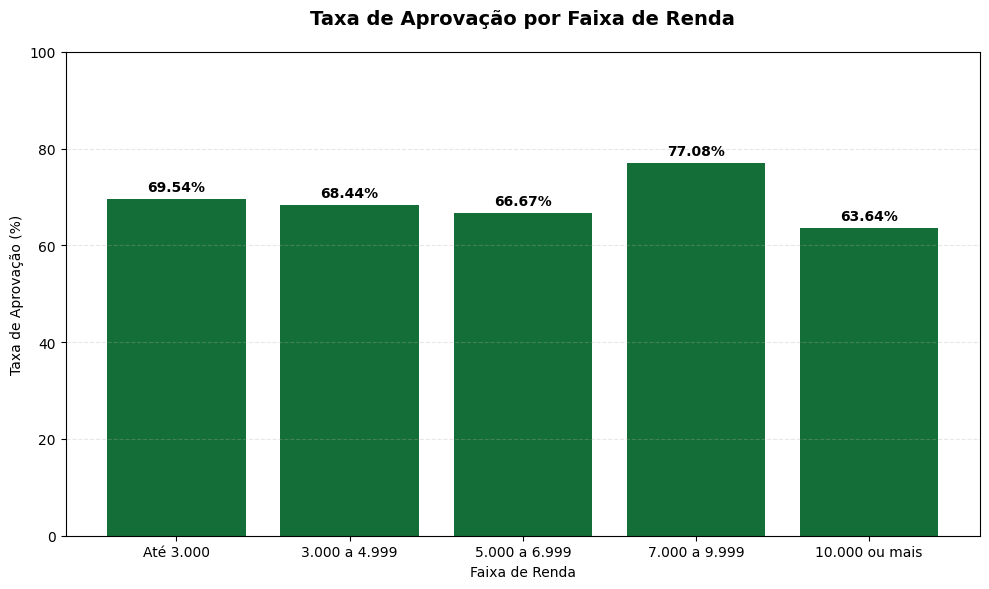

In [0]:
# --- Importação da biblioteca para visualização ---
import matplotlib.pyplot as plt

# --- Preparação dos dados para o gráfico ---
df_renda_aprovacao = _sqldf.toPandas()

# --- Criação do gráfico ---
plt.figure(figsize=(10, 6))

barras = plt.bar(
    df_renda_aprovacao["Faixa_Renda"],
    df_renda_aprovacao["Taxa_Aprovacao"],
    color = "#146E37"
)

# --- Adição dos rótulos de dados ---
for barra, valor in zip(barras, df_renda_aprovacao["Taxa_Aprovacao"]):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# --- Configuração do gráfico ---
plt.title(
    "Taxa de Aprovação por Faixa de Renda",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.xlabel("Faixa de Renda")
plt.ylabel("Taxa de Aprovação (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
%sql
-- Correlação das medidas de renda com a aprovação

SELECT
    ROUND(
        CORR(
            ApplicantIncome,
            CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END
        ), 4
    ) AS Correlacao_Renda_Solicitante,

    ROUND(
        CORR(
            Renda_Familiar,
            CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END
        ), 4
    ) AS Correlacao_Renda_Familiar

FROM workspace.default.loan_approval_gold;

Correlacao_Renda_Solicitante,Correlacao_Renda_Familiar
-0.0047,-0.0313


### 5.2.1 Resultado da Análise

As taxas de aprovação não apresentaram um comportamento crescente conforme o aumento da renda. Entre as faixas analisadas, a maior taxa de aprovação ocorreu entre 7.000 e 9.999, com 77,08%, enquanto a faixa de 10.000 ou mais apresentou taxa de 63,64%.

A análise de correlação reforçou esse comportamento. A correlação entre a renda do solicitante e a aprovação foi de -0,0047, enquanto a renda familiar apresentou correlação de -0,0313. Como ambos os valores estão muito próximos de zero, não foi observada uma relação linear relevante entre essas medidas de renda e a aprovação do empréstimo.

Dessa forma, neste conjunto de dados, níveis maiores de renda não estão associados de forma consistente a maiores taxas de aprovação.

## 5.3 Influência do Histórico de Crédito na Aprovação

A segunda análise busca avaliar a relação entre o histórico de crédito e a aprovação dos empréstimos. Para isso, será calculada a taxa de aprovação para os solicitantes de acordo com o indicador `Credit_History`.

In [0]:
%sql
-- Distribuição da aprovação por histórico de crédito

SELECT
    Credit_History,
    COUNT(*) AS Solicitacoes,

    ROUND(
        SUM(CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS Taxa_Aprovacao,

    ROUND(
        SUM(CASE WHEN Loan_Status = 'N' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS Taxa_Reprovacao

FROM workspace.default.loan_approval_gold
GROUP BY Credit_History
ORDER BY Credit_History;

Credit_History,Solicitacoes,Taxa_Aprovacao,Taxa_Reprovacao
0,89,7.87,92.13
1,525,79.05,20.95


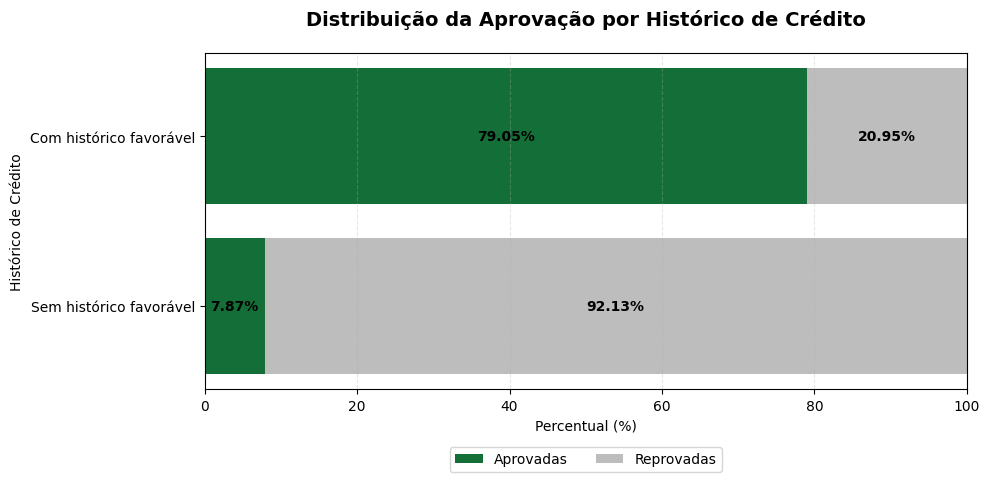

In [0]:
# --- Importação da biblioteca para visualização ---
import matplotlib.pyplot as plt

# --- Preparação dos dados para o gráfico ---
df_historico_aprovacao = _sqldf.toPandas()

# --- Ajuste dos rótulos do histórico de crédito ---
df_historico_aprovacao["Historico_Credito"] = (
    df_historico_aprovacao["Credit_History"]
    .map({
        0: "Sem histórico favorável",
        1: "Com histórico favorável"
    })
)

# --- Criação do gráfico ---
fig, ax = plt.subplots(figsize=(10, 5))

barras_aprovadas = ax.barh(
    df_historico_aprovacao["Historico_Credito"],
    df_historico_aprovacao["Taxa_Aprovacao"],
    color="#146E37",
    label="Aprovadas"
)

barras_reprovadas = ax.barh(
    df_historico_aprovacao["Historico_Credito"],
    df_historico_aprovacao["Taxa_Reprovacao"],
    left=df_historico_aprovacao["Taxa_Aprovacao"],
    color="#BDBDBD",
    label="Reprovadas"
)

# --- Adição dos rótulos de dados ---
for i, linha in df_historico_aprovacao.iterrows():
    aprovacao = linha["Taxa_Aprovacao"]
    reprovacao = linha["Taxa_Reprovacao"]

    ax.text(
        aprovacao / 2,
        i,
        f"{aprovacao:.2f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )

    ax.text(
        aprovacao + reprovacao / 2,
        i,
        f"{reprovacao:.2f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )

# --- Configuração do gráfico ---
ax.set_title(
    "Distribuição da Aprovação por Histórico de Crédito",
    fontsize=14,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Percentual (%)")
ax.set_ylabel("Histórico de Crédito")
ax.set_xlim(0, 100)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
%sql
-- Correlação entre histórico de crédito e aprovação

SELECT
    ROUND(
        CORR(
            Credit_History,
            CASE
                WHEN Loan_Status = 'Y' THEN 1
                ELSE 0
            END
        ), 4
    ) AS Correlacao_Historico_Aprovacao
FROM workspace.default.loan_approval_gold;

Correlacao_Historico_Aprovacao
0.5406


### 5.3.1 Resultado da Análise

O histórico de crédito apresentou uma relação clara com a aprovação dos empréstimos. Entre os solicitantes com histórico de crédito favorável, 79,05% das solicitações foram aprovadas. Entre aqueles sem histórico favorável, a taxa de aprovação foi de apenas 7,87%.

A correlação entre o histórico de crédito e a aprovação foi de 0,5406, indicando uma relação positiva moderada entre as variáveis. O resultado mostra que, neste conjunto de dados, a presença de um histórico de crédito favorável está associada a uma frequência maior de aprovação das solicitações.

## 5.4 Relação entre Valor Solicitado e Aprovação

A terceira análise busca avaliar a relação entre o valor solicitado do empréstimo e sua aprovação. Para isso, serão comparadas as taxas de aprovação em diferentes faixas de valor, permitindo observar se o comportamento da aprovação se altera conforme o montante solicitado.

In [0]:
%sql
-- Relação entre valor solicitado e aprovação

SELECT
    CASE
        WHEN LoanAmount < 100 THEN 'Até 99 mil'
        WHEN LoanAmount < 150 THEN '100 a 149 mil'
        WHEN LoanAmount < 200 THEN '150 a 199 mil'
        WHEN LoanAmount < 300 THEN '200 a 299 mil'
        ELSE '300 mil ou mais'
    END AS Faixa_Valor_Solicitado,

    COUNT(*) AS Solicitacoes,

    SUM(
        CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END
    ) AS Aprovadas,

    ROUND(
        SUM(CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS Taxa_Aprovacao

FROM workspace.default.loan_approval_gold

GROUP BY Faixa_Valor_Solicitado

ORDER BY MIN(LoanAmount);

Faixa_Valor_Solicitado,Solicitacoes,Aprovadas,Taxa_Aprovacao
Até 99 mil,139,96,69.06
100 a 149 mil,268,191,71.27
150 a 199 mil,122,81,66.39
200 a 299 mil,55,36,65.45
300 mil ou mais,30,18,60.00


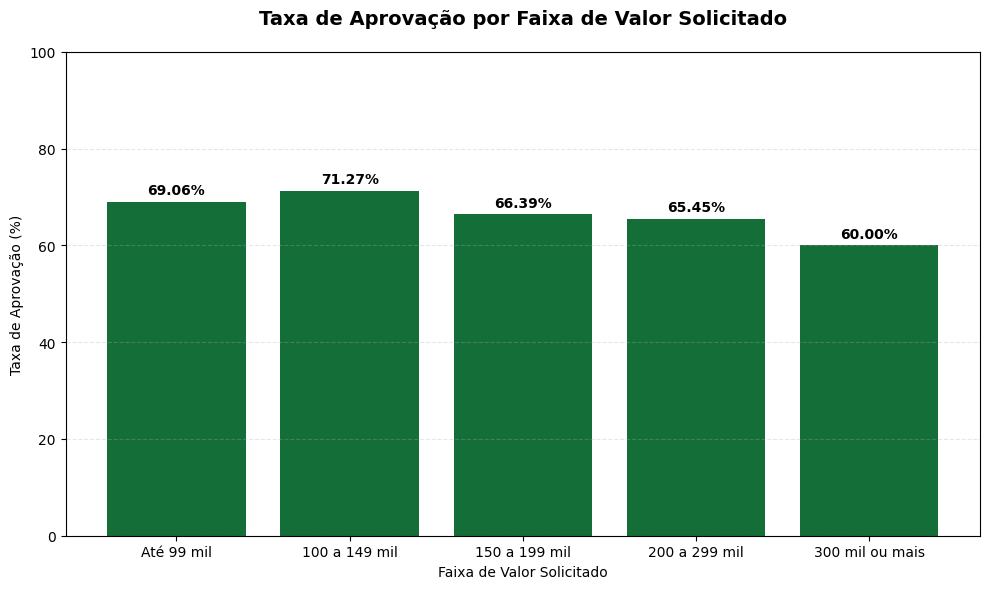

In [0]:
# --- Preparação dos dados para o gráfico ---
df_valor_aprovacao = _sqldf.toPandas()

# --- Criação do gráfico ---
plt.figure(figsize=(10, 6))

barras = plt.bar(
    df_valor_aprovacao["Faixa_Valor_Solicitado"],
    df_valor_aprovacao["Taxa_Aprovacao"],
    color="#146E37"
)

# --- Adição dos rótulos de dados ---
for barra, valor in zip(barras, df_valor_aprovacao["Taxa_Aprovacao"]):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# --- Configuração do gráfico ---
plt.title(
    "Taxa de Aprovação por Faixa de Valor Solicitado",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.xlabel("Faixa de Valor Solicitado")
plt.ylabel("Taxa de Aprovação (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
%sql
-- Correlação entre valor solicitado e aprovação

SELECT
    ROUND(
        CORR(
            LoanAmount,
            CASE
                WHEN Loan_Status = 'Y' THEN 1
                ELSE 0
            END
        ), 4
    ) AS Correlacao_Valor_Aprovacao
FROM workspace.default.loan_approval_gold;

Correlacao_Valor_Aprovacao
-0.0329


### 5.4.1 Resultado da Análise

As taxas de aprovação apresentaram algumas diferenças entre as faixas de valor solicitado. A maior taxa de aprovação foi observada entre 100 e 149 mil, com 71,27%, enquanto solicitações de 300 mil ou mais apresentaram a menor taxa de aprovação, com 60,00%.

Apesar da redução observada nas faixas de maior valor, a correlação entre o valor solicitado e a aprovação foi de -0,0329, valor muito próximo de zero. Dessa forma, não foi identificada uma relação linear relevante entre o valor solicitado e a aprovação dos empréstimos neste conjunto de dados.

Os resultados indicam que o valor solicitado, quando analisado isoladamente, não apresenta uma associação consistente com a aprovação.

## 5.5 Comprometimento Estimado da Renda Familiar

A próxima análise busca avaliar a relação entre o comprometimento estimado da renda familiar e a aprovação das solicitações. Para isso, serão comparadas as taxas de aprovação em diferentes faixas de comprometimento da renda, além da análise da correlação entre o percentual de comprometimento e a situação da solicitação.

In [0]:
%sql
-- Relação entre comprometimento de renda e aprovação

SELECT
    CASE
        WHEN Percentual_Comprometimento_Renda < 5 THEN 'Menos de 5%'
        WHEN Percentual_Comprometimento_Renda < 10 THEN '5% a 9,99%'
        WHEN Percentual_Comprometimento_Renda < 20 THEN '10% a 19,99%'
        ELSE '20% ou mais'
    END AS Faixa_Comprometimento,

    COUNT(*) AS Solicitacoes,

    SUM(
        CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END
    ) AS Aprovadas,

    ROUND(
        SUM(CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS Taxa_Aprovacao

FROM workspace.default.loan_approval_gold

GROUP BY Faixa_Comprometimento

ORDER BY MIN(Percentual_Comprometimento_Renda);

Faixa_Comprometimento,Solicitacoes,Aprovadas,Taxa_Aprovacao
Menos de 5%,107,71,66.36
"5% a 9,99%",444,319,71.85
"10% a 19,99%",53,25,47.17
20% ou mais,10,7,70.00


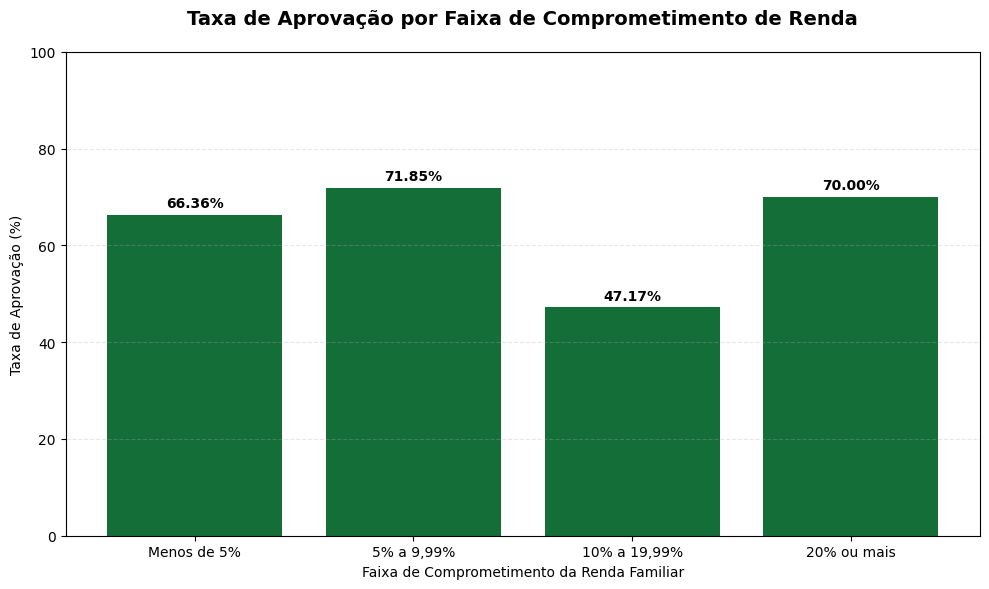

In [0]:
# --- Preparação dos dados para o gráfico ---
df_comprometimento_aprovacao = _sqldf.toPandas()

# --- Criação do gráfico ---
plt.figure(figsize=(10, 6))

barras = plt.bar(
    df_comprometimento_aprovacao["Faixa_Comprometimento"],
    df_comprometimento_aprovacao["Taxa_Aprovacao"],
    color="#146E37"
)

# --- Adição dos rótulos de dados ---
for barra, valor in zip(
    barras,
    df_comprometimento_aprovacao["Taxa_Aprovacao"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# --- Configuração do gráfico ---
plt.title(
    "Taxa de Aprovação por Faixa de Comprometimento de Renda",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.xlabel("Faixa de Comprometimento da Renda Familiar")
plt.ylabel("Taxa de Aprovação (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
%sql
-- Correlação entre comprometimento de renda e aprovação

SELECT
    ROUND(
        CORR(
            Percentual_Comprometimento_Renda,
            CASE
                WHEN Loan_Status = 'Y' THEN 1
                ELSE 0
            END
        ), 4
    ) AS Correlacao_Comprometimento_Aprovacao

FROM workspace.default.loan_approval_gold;

Correlacao_Comprometimento_Aprovacao
-0.051


### 5.5.1 Resultado da Análise

As taxas de aprovação apresentaram variações entre as diferentes faixas de comprometimento estimado da renda familiar. A faixa entre 5% e 9,99% apresentou taxa de aprovação de 71,85%, enquanto a faixa entre 10% e 19,99% apresentou a menor taxa, de 47,17%.

Para comprometimentos de 20% ou mais, a taxa de aprovação foi de 70,00%. Entretanto, essa faixa contém apenas 10 solicitações, quantidade significativamente inferior às demais, o que limita a interpretação desse resultado.

A correlação entre o percentual de comprometimento da renda e a aprovação foi de -0,0510, indicando uma relação linear negativa muito fraca e próxima de zero. Dessa forma, não foi identificada uma relação linear relevante entre o comprometimento estimado da renda familiar e a aprovação das solicitações neste conjunto de dados.

## 5.6 Relação entre Renda e Valor Solicitado

Nessa análise busco avaliar avaliar conjuntamente a renda do solicitante, o valor solicitado do empréstimo e a situação da solicitação. O objetivo é verificar como a relação entre renda e valor solicitado se comporta entre solicitações aprovadas e reprovadas.

In [0]:
%sql
-- Correlação entre renda e valor solicitado por situação da solicitação

SELECT
    Loan_Status,
    COUNT(*) AS Solicitacoes,

    ROUND(
        CORR(
            ApplicantIncome,
            LoanAmount
        ),
        4
    ) AS Correlacao_Renda_Valor

FROM workspace.default.loan_approval_gold

GROUP BY Loan_Status

ORDER BY Loan_Status;

Loan_Status,Solicitacoes,Correlacao_Renda_Valor
N,192,0.4803
Y,422,0.6135


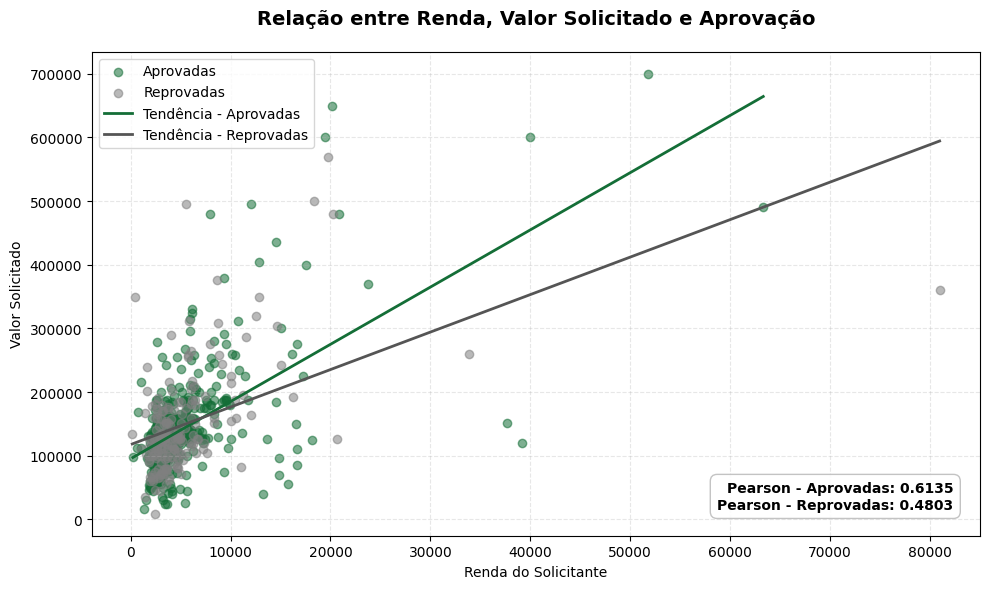

In [0]:
# --- Carregamento dos dados ---
df_renda_valor = spark.sql("""
    SELECT
        ApplicantIncome,
        LoanAmount,
        Loan_Status
    FROM workspace.default.loan_approval_gold
""").toPandas()

# --- Ajuste do valor solicitado ---
df_renda_valor["Valor_Solicitado"] = (
    df_renda_valor["LoanAmount"] * 1000
)

# --- Separação dos grupos ---
aprovadas = df_renda_valor[
    df_renda_valor["Loan_Status"] == "Y"
]

reprovadas = df_renda_valor[
    df_renda_valor["Loan_Status"] == "N"
]

# --- Criação do gráfico ---
fig, ax = plt.subplots(figsize=(10, 6))

# Aprovadas
ax.scatter(
    aprovadas["ApplicantIncome"],
    aprovadas["Valor_Solicitado"],
    color="#146E37",
    alpha=0.55,
    label="Aprovadas"
)

# Reprovadas
ax.scatter(
    reprovadas["ApplicantIncome"],
    reprovadas["Valor_Solicitado"],
    color="#808080",
    alpha=0.55,
    label="Reprovadas"
)

# --- Linhas de tendência ---
for dados, cor, nome in [
    (aprovadas, "#146E37", "Tendência - Aprovadas"),
    (reprovadas, "#555555", "Tendência - Reprovadas")
]:
    coef = np.polyfit(
        dados["ApplicantIncome"],
        dados["Valor_Solicitado"],
        1
    )

    linha = np.poly1d(coef)

    x = np.linspace(
        dados["ApplicantIncome"].min(),
        dados["ApplicantIncome"].max(),
        100
    )

    ax.plot(
        x,
        linha(x),
        color=cor,
        linewidth=2,
        label=nome
    )

# --- Correlações ---
ax.text(
    0.97,
    0.05,
    "Pearson - Aprovadas: 0.6135\nPearson - Reprovadas: 0.4803",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#BDBDBD",
        alpha=0.9
    )
)

# --- Configurações ---
ax.set_title(
    "Relação entre Renda, Valor Solicitado e Aprovação",
    fontsize=14,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Renda do Solicitante")
ax.set_ylabel("Valor Solicitado")
ax.grid(linestyle="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### 5.6.1 Resultado da Análise

A análise conjunta da renda do solicitante, do valor solicitado e da situação da solicitação identificou associação positiva entre renda e valor solicitado tanto nas solicitações aprovadas quanto nas reprovadas.

Entre as solicitações aprovadas, a correlação de Pearson entre renda e valor solicitado foi de 0,6135, enquanto entre as solicitações reprovadas foi de 0,4803. Os resultados indicam uma associação positiva moderada nos dois grupos, sendo mais forte entre as solicitações aprovadas.

O gráfico de dispersão também demonstra considerável sobreposição entre as solicitações aprovadas e as solicitações reprovadas. Dessa forma, ainda que renda e valor solicitado apresentem relação entre si, a relação entre essas duas variáveis quando observada conjuntamente, não estabelece uma separação clara entre as solicitações aprovadas e reprovadas.

## 5.7 Variáveis Associadas à Aprovação

A próxima análise busca identificar quais variáveis apresentam maior associação com a aprovação das solicitações de empréstimo. Para as variáveis numéricas será utilizada a correlação de Pearson, enquanto para as variáveis categóricas será utilizado o V de Cramér. Os resultados serão apresentados conjuntamente como uma visão exploratória das associações, considerando que as métricas possuem interpretações distintas e não devem ser comparadas como medidas diretamente equivalentes.

In [0]:
# --- Importação das bibliotecas ---
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# --- Seleção dos dados para análise de associação ---
df_associacao = (
    spark.table("workspace.default.loan_approval_gold")
    .drop("Loan_ID")
    .toPandas()
)

# --- Conversão da aprovação para formato numérico ---
df_associacao["Loan_Status_Target"] = (
    df_associacao["Loan_Status"]
    .map({
        "N": 0,
        "Y": 1
    })
)

# --- Definição das variáveis numéricas ---
variaveis_numericas = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Renda_Familiar",
    "Parcela_Mensal_Estimada",
    "Percentual_Comprometimento_Renda"
]

# --- Definição das variáveis categóricas ---
variaveis_categoricas = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

# --- Lista para armazenar os resultados ---
resultados_associacao = []

# --- Associação das variáveis numéricas com a aprovação ---
for variavel in variaveis_numericas:

    correlacao = df_associacao[variavel].corr(
        df_associacao["Loan_Status_Target"]
    )

    resultados_associacao.append({
        "Variavel": variavel,
        "Tipo": "Numérica",
        "Metrica": "Pearson",
        "Associacao": correlacao,
        "Forca_Associacao": abs(correlacao)
    })

# --- Associação das variáveis categóricas com a aprovação ---
for variavel in variaveis_categoricas:

    tabela_contingencia = pd.crosstab(
        df_associacao[variavel],
        df_associacao["Loan_Status"]
    )

    qui_quadrado = chi2_contingency(
        tabela_contingencia
    )[0]

    n = tabela_contingencia.to_numpy().sum()

    minimo_dimensao = min(
        tabela_contingencia.shape[0] - 1,
        tabela_contingencia.shape[1] - 1
    )

    cramers_v = np.sqrt(
        qui_quadrado /
        (n * minimo_dimensao)
    )

    resultados_associacao.append({
        "Variavel": variavel,
        "Tipo": "Categórica",
        "Metrica": "V de Cramér",
        "Associacao": cramers_v,
        "Forca_Associacao": cramers_v
    })

# --- Criação e ordenação da tabela final ---
df_resultados_associacao = (
    pd.DataFrame(resultados_associacao)
    .sort_values(
        "Forca_Associacao",
        ascending=False
    )
    .reset_index(drop=True)
)

# --- Exibição dos resultados ---
display(
    df_resultados_associacao.round(4)
)

Variavel,Tipo,Metrica,Associacao,Forca_Associacao
Credit_History,Numérica,Pearson,0.5406,0.5406
Property_Area,Categórica,V de Cramér,0.1415,0.1415
Married,Categórica,V de Cramér,0.0878,0.0878
Education,Categórica,V de Cramér,0.0816,0.0816
Dependents,Categórica,V de Cramér,0.0716,0.0716
CoapplicantIncome,Numérica,Pearson,-0.0592,0.0592
Percentual_Comprometimento_Renda,Numérica,Pearson,-0.051,0.051
LoanAmount,Numérica,Pearson,-0.0329,0.0329
Renda_Familiar,Numérica,Pearson,-0.0313,0.0313
Loan_Amount_Term,Numérica,Pearson,-0.0225,0.0225


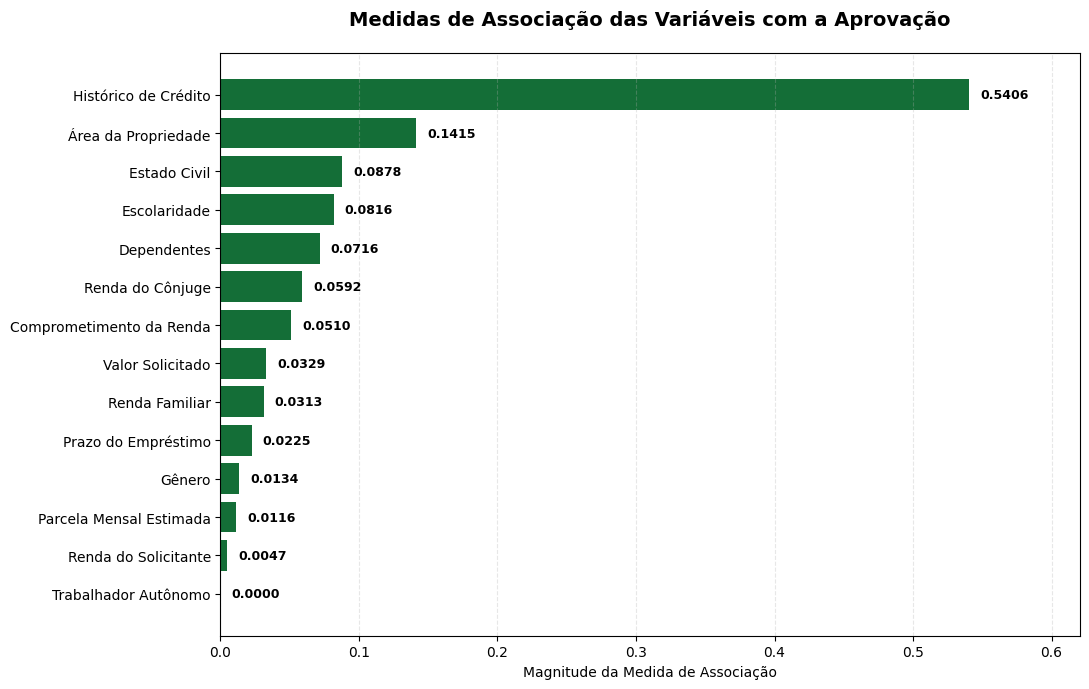

In [0]:
# --- Nomes das variáveis em português ---
nomes_variaveis = {
    "Credit_History": "Histórico de Crédito",
    "Property_Area": "Área da Propriedade",
    "Married": "Estado Civil",
    "Education": "Escolaridade",
    "Dependents": "Dependentes",
    "CoapplicantIncome": "Renda do Cônjuge",
    "Percentual_Comprometimento_Renda": "Comprometimento da Renda",
    "LoanAmount": "Valor Solicitado",
    "Renda_Familiar": "Renda Familiar",
    "Loan_Amount_Term": "Prazo do Empréstimo",
    "Gender": "Gênero",
    "Parcela_Mensal_Estimada": "Parcela Mensal Estimada",
    "ApplicantIncome": "Renda do Solicitante",
    "Self_Employed": "Trabalhador Autônomo"
}

# --- Preparação dos dados ---
df_grafico_associacao = df_resultados_associacao.copy()

df_grafico_associacao["Variavel_PT"] = (
    df_grafico_associacao["Variavel"]
    .map(nomes_variaveis)
)

# Ordenação pela magnitude da medida de associação
df_grafico_associacao = (
    df_grafico_associacao
    .sort_values("Forca_Associacao", ascending=True)
)

# --- Criação do gráfico ---
fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    df_grafico_associacao["Variavel_PT"],
    df_grafico_associacao["Forca_Associacao"],
    color="#146E37"
)

# --- Rótulos dos valores ---
for barra, valor in zip(
    barras,
    df_grafico_associacao["Forca_Associacao"]
):
    ax.text(
        barra.get_width() + 0.008,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.4f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

# --- Configurações ---
ax.set_title(
    "Medidas de Associação das Variáveis com a Aprovação",
    fontsize=14,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Magnitude da Medida de Associação")
ax.set_ylabel("")

ax.set_xlim(
    0,
    df_grafico_associacao["Forca_Associacao"].max() + 0.08
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 5.7.1 Resultado da Análise

Entre as variáveis numéricas, o Histórico de Crédito apresentou a associação mais expressiva com a aprovação das solicitações, com coeficiente de Pearson de 0,5406. As demais variáveis numéricas apresentaram correlações de baixa magnitude com a aprovação.

Entre as variáveis categóricas, a Área da Propriedade apresentou o maior V de Cramér, com 0,1415, seguida por Estado Civil (0,0878), Escolaridade (0,0816) e Dependentes (0,0716).

Esse resultado complementa a análise realizada na seção 5.6, onde foi identificada uma associação positiva entre a renda do solicitante e o valor solicitado, sendo essa relação mais forte entre as solicitações aprovadas (0,6135) do que entre as reprovadas (0,4803). Entretanto, quando a renda e o valor solicitado são avaliados individualmente em relação à aprovação, apresentam associações de baixa magnitude.

De modo geral, o Histórico de Crédito se destacou entre as variáveis numéricas analisadas, enquanto a Área da Propriedade apresentou a maior associação entre as variáveis categóricas. Os resultados também reforçam que renda e valor solicitado, quando considerados isoladamente, apresentam pouca relação com a aprovação neste conjunto de dados.

Para as variáveis numéricas foi utilizada a correlação de Pearson, enquanto para as variáveis categóricas foi utilizado o V de Cramér. Como são medidas diferentes, os valores devem ser analisados de acordo com cada métrica. Os resultados indicam o quanto cada variável está associada à aprovação dentro deste conjunto de dados, mas não significam, necessariamente, que uma variável seja responsável pela aprovação ou reprovação de uma solicitação.

## 5.8 Síntese dos Resultados

As análises realizadas permitiram responder às perguntas definidas para o projeto e observar que a aprovação das solicitações apresenta diferentes níveis de associação com as características disponíveis na base.

Os resultados mostraram que renda, valor solicitado e comprometimento estimado da renda familiar, quando avaliados individualmente, apresentaram pouca relação com a aprovação. Também foi observado que a renda do solicitante e o valor solicitado possuem relação positiva entre si, tanto nas solicitações aprovadas quanto nas reprovadas, sendo essa relação mais forte entre as solicitações aprovadas.

Entre as variáveis numéricas analisadas, o Histórico de Crédito apresentou a associação mais expressiva com a aprovação, com coeficiente de Pearson de 0,5406. Entre as variáveis categóricas, a Área da Propriedade apresentou o maior V de Cramér, com 0,1415. As demais variáveis apresentaram associações de menor magnitude dentro de suas respectivas métricas.

De modo geral, os resultados mostram que nenhuma característica deve ser analisada isoladamente para explicar o resultado das solicitações. O Histórico de Crédito foi a variável que mais se destacou nas análises realizadas, enquanto as demais características contribuíram para ampliar a compreensão do comportamento observado nos dados.

Ao final, os dados preparados ao longo do pipeline permitiram responder às questões propostas no início do projeto e demonstraram a utilização das camadas Bronze, Silver e Gold para transformar os dados originais em informações estruturadas e disponíveis para análise.

# 6. Conclusão

## 6.1 Considerações Finais

O desenvolvimento deste projeto permitiu construir um pipeline de dados completo no Databricks, partindo dos dados brutos até a disponibilização de informações preparadas para análise. A utilização da arquitetura Medalhão possibilitou organizar esse processo em diferentes etapas, mantendo os dados originais na camada Bronze, realizando os tratamentos necessários na Silver e disponibilizando na Gold os dados e indicadores utilizados nas análises.

Ao longo do pipeline foram realizadas etapas de ingestão, transformação, tratamento, validação da qualidade e organização dos dados. A criação de novas variáveis, como renda familiar, parcela mensal estimada e percentual de comprometimento da renda, também permitiu ampliar as possibilidades de análise a partir da base original.

Com os dados preparados, foi possível responder às perguntas propostas no início do projeto e identificar diferentes relações entre as características dos solicitantes e o resultado das solicitações. Entre os resultados encontrados, o histórico de crédito apresentou a relação mais evidente com a aprovação, enquanto outras variáveis mostraram relações menos expressivas quando analisadas individualmente.

Além dos resultados obtidos nas análises, o projeto permitiu aplicar na prática conceitos relacionados à Engenharia de Dados, passando pela ingestão, organização, transformação e validação dos dados até sua disponibilização para análise. Ao final do processo, foi construído um pipeline estruturado em camadas, capaz de transformar os dados brutos em informações preparadas para responder às perguntas definidas no início do projeto.

## 6.2 Limitações do Projeto

Uma das principais limitações do projeto está relacionada ao conjunto de dados. A base possui 614 registros e um número limitado de variáveis, o que restringe a análise a um conjunto específico de características dos solicitantes e das solicitações de empréstimo.

Algumas variáveis também apresentaram poucos dados. Na análise do comprometimento da renda, por exemplo, as faixas mais elevadas concentraram poucos registros, dificultando uma interpretação mais consistente do comportamento desses grupos.

Outra limitação está relacionada às informações disponíveis sobre o processo de concessão do crédito. A base apresenta o resultado final da solicitação, porém não informa os critérios ou regras utilizados para a decisão. Dessa forma, as relações encontradas ao longo das análises indicam associações presentes nos dados, mas não permitem determinar quais fatores foram efetivamente utilizados no processo de aprovação.

Além disso, variáveis que poderiam contribuir para uma análise mais completa do risco de crédito, como outras dívidas existentes, comportamento de pagamento, restrições financeiras e relacionamento anterior com a instituição, não estão disponíveis na base utilizada.

## 6.3 Trabalhos Futuros

Com esse pipeline desenvolvido, o projeto serve como ponto de partida para a inclusão de novas fontes de dados e variáveis relacionadas ao comportamento financeiro dos solicitantes. Informações sobre histórico de pagamentos, dívidas existentes, restrições financeiras e relacionamento com a instituição que podem servir para ampliar as possibilidades de análise.

O pipeline também poderá ser adaptado para receber novos dados de forma periódica, permitindo a atualização das camadas Bronze, Silver e Gold e, consequentemente, das análises realizadas a partir delas.

Outra possibilidade seria utilizar os dados preparados na camada Gold como base para modelos de Machine Learning voltados à previsão da aprovação das solicitações. Essa etapa permitiria avançar da análise das relações encontradas nos dados para a construção e avaliação de modelos preditivos.

## 6.4 Autoavaliação

O desenvolvimento deste MVP permitiu aplicar na prática as principais etapas envolvidas na construção de um pipeline de dados em ambiente de nuvem. Os objetivos definidos no início do projeto foram alcançados, desde a ingestão e organização dos dados até sua transformação e disponibilização para análise. As perguntas de negócio propostas também puderam ser exploradas a partir dos dados preparados ao longo do pipeline.

Durante o desenvolvimento, uma das principais dificuldades foi estruturar corretamente as diferentes etapas do pipeline e definir quais tratamentos deveriam ser realizados em cada camada. A análise da qualidade dos dados também exigiu atenção, principalmente na identificação de valores ausentes, possíveis outliers e na decisão de quais registros deveriam ser mantidos ou tratados. Outro ponto importante foi a criação dos atributos derivados utilizados nas análises, buscando manter os cálculos coerentes com as informações disponíveis na base.

A utilização do Databricks também contribuiu para ampliar o conhecimento sobre armazenamento, transformação e persistência de dados utilizando Spark, SQL, Delta Lake e Unity Catalog. Ao longo do desenvolvimento, foi possível compreender melhor a função das camadas Bronze, Silver e Gold e como elas contribuem para organizar as diferentes etapas de um pipeline.

De forma geral, o desenvolvimento do MVP contribuiu para consolidar os conhecimentos trabalhados na disciplina e permitiu compreender de forma mais prática como as etapas de coleta, tratamento, modelagem, persistência e análise se conectam dentro de um pipeline de dados.